In [ ]:
# Part 2: Exploratory Data Analysis on Retail Store Sales Transactions
# Author: Robert Dakota Robles
# Dataset: Cleaned Retail Store Sales Transactions
# Description: This EDA uncovers patterns in product popularity, revenue trends, customer behavior, and overall sales performance.

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the dataset
sales = pd.read_csv("/content/cleaned_retail_sales (1).csv")

print(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   invoice id               1000 non-null   object 
 1   branch                   1000 non-null   object 
 2   city                     1000 non-null   object 
 3   customer type            994 non-null    object 
 4   gender                   1000 non-null   object 
 5   product line             1000 non-null   object 
 6   unit price               1000 non-null   float64
 7   quantity                 1000 non-null   int64  
 8   tax 5%                   1000 non-null   float64
 9   total                    1000 non-null   float64
 10  date                     1000 non-null   object 
 11  time                     1000 non-null   object 
 12  payment                  994 non-null    object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
# Starting data overview
sales.describe()
print(sales.head())

,unit price,quantity,tax 5%,total,cogs,gross margin percentage,gross income,rating,day,month,year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000,1000.000000,1000.0
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97430,15.256000,1.993000,2019.0
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71457,8.693563,0.835254,0.0
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000,1.000000,1.000000,2019.0
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000,8.000000,1.000000,2019.0
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000,15.000000,2.000000,2019.0
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.42500,23.000000,3.000000,2019.0
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000,31.000000,3.000000,2019.0


EDA is all about answering meaningful business questions. Here are a few we can explore:

🔹 Sales Performance
- What are the top-selling product lines?
- Which store branch generates the highest revenue?
- What are the peak sales hours?

🔹 Customer Behavior
- How do different customer types (members vs. normal) impact sales?
- What payment methods do customers prefer?
- How do customer ratings vary across product lines?

🔹 Time-Based Trends
- How do sales vary by day and month?
- Are there any noticeable trends in total revenue over time?

<ipython-input-7-8b3d952a32c2>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales['product line'].value_counts().index,


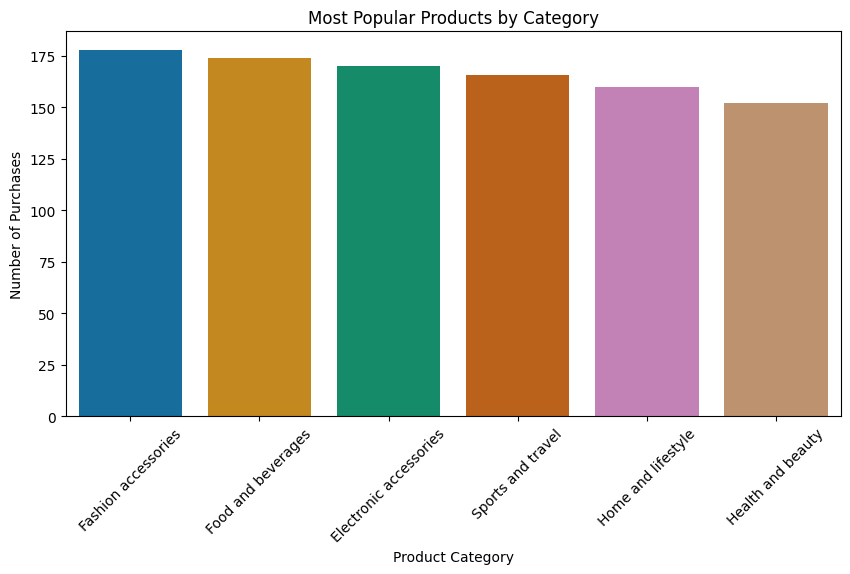

In [ ]:
#Showing the most popular product categories

plt.figure(figsize=(10, 5))
sns.barplot(x=sales['product line'].value_counts().index,
            y=sales['product line'].value_counts().values,
            palette="colorblind")
plt.xticks(rotation=45)
plt.title("Most Popular Products by Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.show()

<ipython-input-8-0a3e47f549ae>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_revenue['branch'], y=branch_revenue['total'], palette = "colorblind", order=branch_revenue.sort_values('total', ascending=False)['branch'])


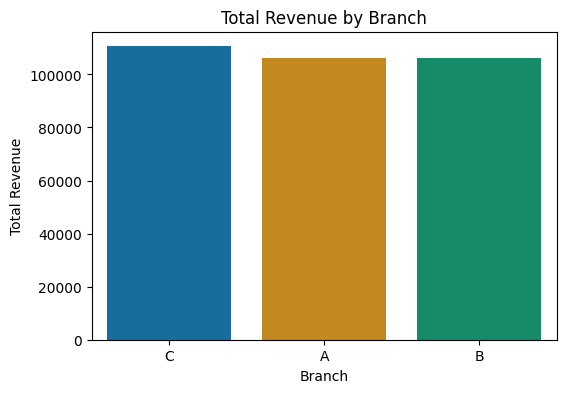

In [ ]:
#Showing total sales revenue by branch
branch_revenue = sales.groupby("branch")['total'].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x=branch_revenue['branch'], y=branch_revenue['total'], palette = "colorblind", order=branch_revenue.sort_values('total', ascending=False)['branch'])
plt.title("Total Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Revenue")
plt.show()

<ipython-input-17-4ee1f85adb31>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales["hour"] = pd.to_datetime(sales['time']).dt.hour


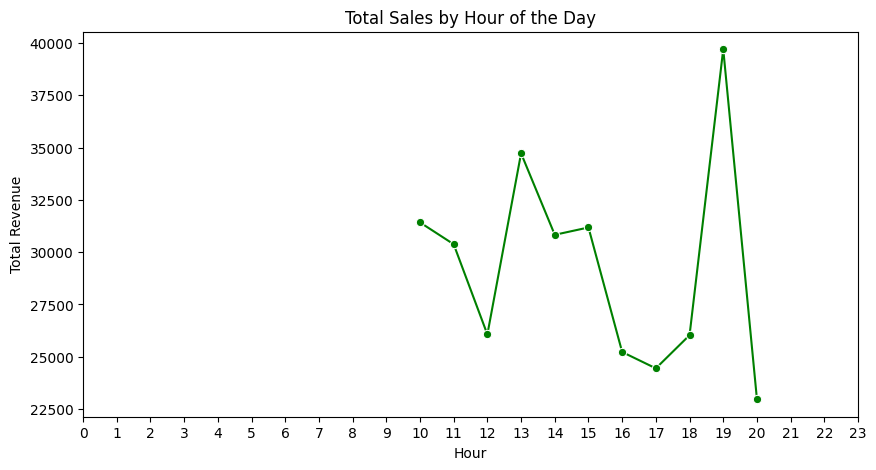

    hour       total
0     10  31421.4810
1     11  30377.3295
2     12  26065.8825
3     13  34723.2270
4     14  30828.3990
5     15  31179.5085
6     16  25226.3235
7     17  24445.2180
8     18  26030.3400
9     19  39699.5130
10    20  22969.5270


In [ ]:
#Showing the most popular store hours
sales["hour"] = pd.to_datetime(sales['time']).dt.hour


hourly_sales = sales.groupby("hour")["total"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="hour", y="total", data=hourly_sales, marker="o", color='green')
plt.title("Total Sales by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Total Revenue")
plt.xticks(range(0,24))
plt.show()

print(hourly_sales)

 Customer Behavior

- How do different customer types (members vs. normal) impact sales?
- What payment methods do customers prefer?
- How do customer ratings vary across product lines?

<ipython-input-10-9405c3f70640>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer type", y="total", data=customer_sales, palette="PuBu")


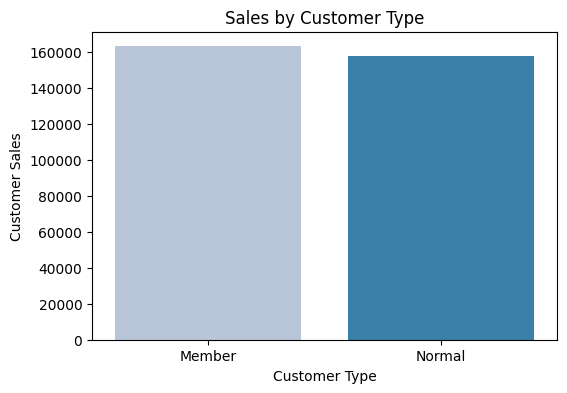

In [ ]:
#Showing sales by type of cutsomer

customer_sales = sales.groupby("customer type")["total"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="customer type", y="total", data=customer_sales, palette="PuBu")
plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Customer Sales")
plt.show()

<ipython-input-11-0bbd72eea4ad>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales['payment'].value_counts().index, y=sales['payment'].value_counts().values, palette="deep")


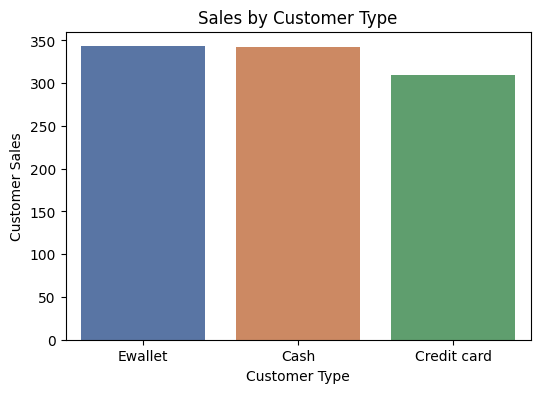

In [ ]:
#Showing frequency of sales transactions by payment type

customer_payments = sales.groupby("payment")["total"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x=sales['payment'].value_counts().index, y=sales['payment'].value_counts().values, palette="deep")
plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Customer Sales")
plt.show()

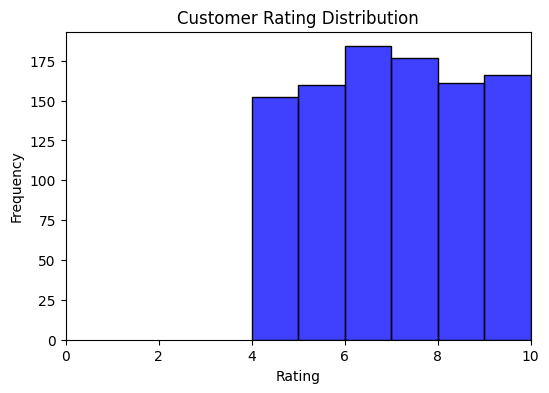

In [ ]:
#Showing the distribution of customer ratings

plt.figure(figsize=(6,4))
sns.histplot(sales["rating"], bins=6, color="blue")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.xlim(0,10)
plt.ylabel("Frequency")
plt.show()

 Time-Based Trends

- How do sales vary by day and month?
- Are there any noticeable trends in total revenue over time?

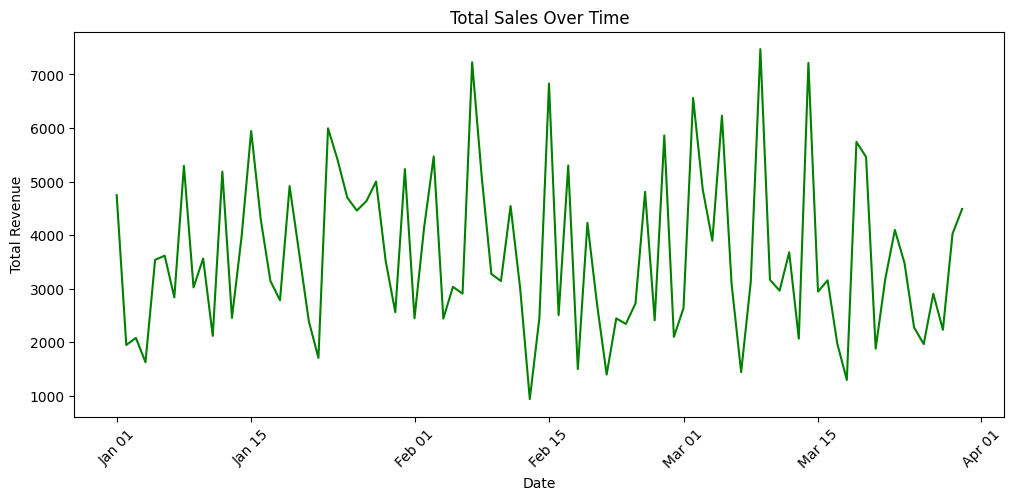

In [ ]:
#Total Sales over time

import matplotlib.dates as mdates

daily_sales = sales.groupby("date")["total"].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x="date", y="total", data=daily_sales, color="green")

plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")

# Format x-axis dates
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())  # Auto-adjust tick spacing
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))  # Format as 'Month Day'

plt.xticks(rotation=45)  # Rotate for better readability
plt.show()